In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [15]:
from ucimlrepo import fetch_ucirepo
online_retail = fetch_ucirepo(id=352)

In [16]:
df = online_retail.data.original
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as mticker

In [18]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n")
df.describe()

Shape: (541909, 8)

Data Types:
 InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Basic Stats:



,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [19]:
# Drop rows with missing CustomerID and Description
df.dropna(subset=['CustomerID', 'Description'], inplace=True)

In [20]:
# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [21]:
# Remove rows with negative or zero Quantity and UnitPrice
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [22]:
# Parse InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [23]:
# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [24]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [51]:
# Extract time features
df['Month']      = df['InvoiceDate'].dt.month
df['DayOfWeek']  = df['InvoiceDate'].dt.dayofweek  # 0=Monday
df['Hour']       = df['InvoiceDate'].dt.hour
df['YearMonth']  = df['InvoiceDate'].dt.to_period('M')

# Time features
df["Year"]        = df["InvoiceDate"].dt.year
df["Month"]       = df["InvoiceDate"].dt.month
df["MonthName"]   = df["InvoiceDate"].dt.strftime("%b")
df["Quarter"]     = df["InvoiceDate"].dt.quarter
df["Week"]        = df["InvoiceDate"].dt.isocalendar().week.astype(int)

In [52]:
print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (397884, 18)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,DayOfWeek,Hour,YearMonth,QuantityBin,Year,MonthName,Quarter,Week
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2,8,2010-12,4–6,2010,Dec,4,48
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2,8,2010-12,4–6,2010,Dec,4,48
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2,8,2010-12,7–12,2010,Dec,4,48
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2,8,2010-12,4–6,2010,Dec,4,48
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2,8,2010-12,4–6,2010,Dec,4,48


In [53]:
total_revenue    = df['Revenue'].sum()
n_orders         = df['InvoiceNo'].nunique()
n_customers      = df['CustomerID'].nunique()
avg_order_value  = df.groupby('InvoiceNo')['Revenue'].sum().mean()
top_country      = df.groupby('Country')['Revenue'].sum().idxmax()

print(f"Total Revenue      : £{total_revenue:,.2f}")
print(f"Unique Orders      : {n_orders:,}")
print(f"Unique Customers   : {n_customers:,}")
print(f"Avg Order Value    : £{avg_order_value:.2f}")
print(f"Top Country        : {top_country}")

Total Revenue      : £8,911,407.90
Unique Orders      : 18,532
Unique Customers   : 4,338
Avg Order Value    : £480.87
Top Country        : United Kingdom


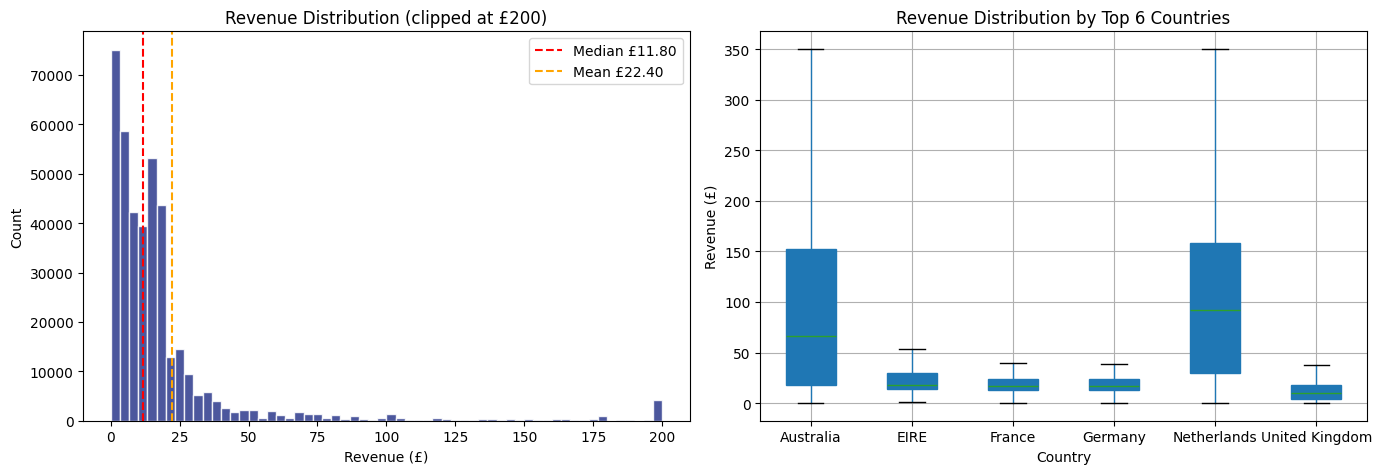

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
rev_clipped = df['Revenue'].clip(0, 200)
axes[0].hist(rev_clipped, bins=60, color='#2D3A8C', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Revenue'].median(), color='red',    linestyle='--', label=f'Median £{df["Revenue"].median():.2f}')
axes[0].axvline(df['Revenue'].mean(),   color='orange', linestyle='--', label=f'Mean £{df["Revenue"].mean():.2f}')
axes[0].set_title('Revenue Distribution (clipped at £200)')
axes[0].set_xlabel('Revenue (£)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot by top countries
top_countries = df.groupby('Country')['Revenue'].sum().nlargest(6).index
df_top = df[df['Country'].isin(top_countries)]
df_top.boxplot(column='Revenue', by='Country', ax=axes[1], 
               patch_artist=True, showfliers=False)
axes[1].set_title('Revenue Distribution by Top 6 Countries')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Revenue (£)')
plt.suptitle('')
plt.tight_layout()
plt.show()

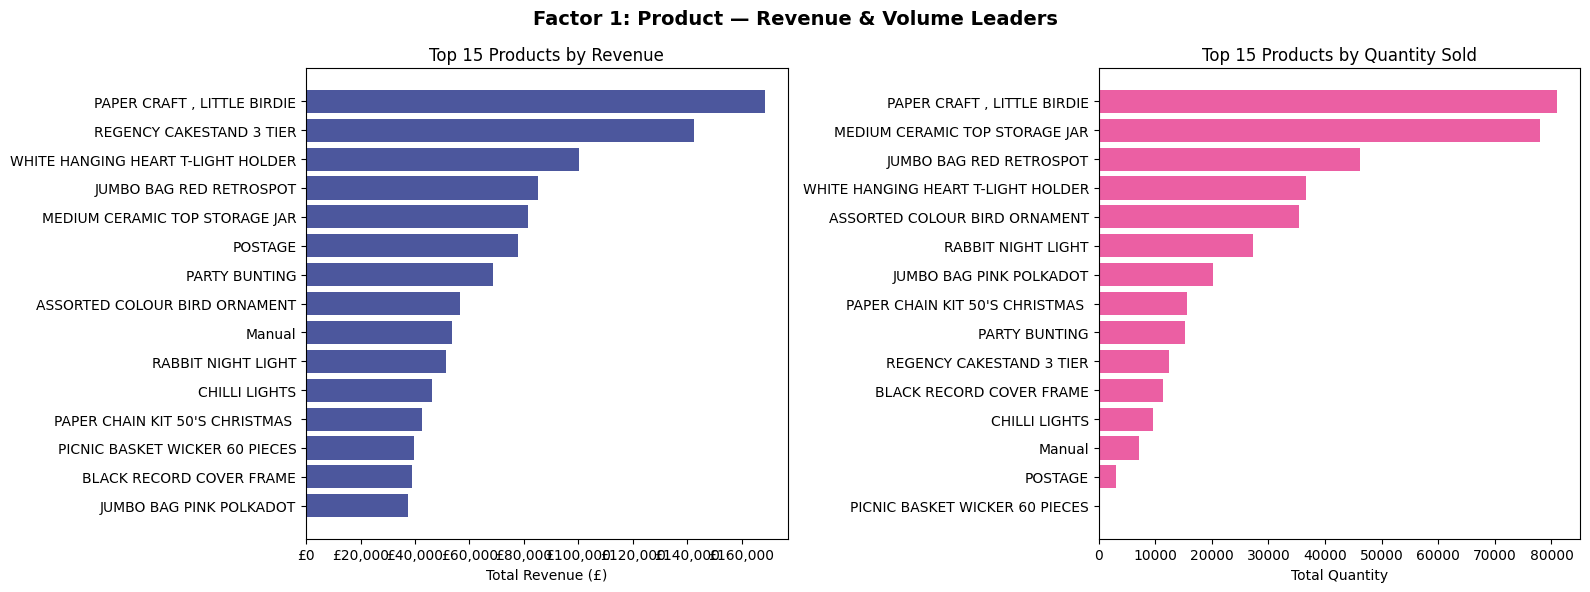

In [55]:
cat_rev = df.groupby('Description').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Num_Transactions=('InvoiceNo', 'count')
).sort_values('Total_Revenue', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 products by revenue
axes[0].barh(cat_rev.index[::-1], cat_rev['Total_Revenue'][::-1], color='#2D3A8C', alpha=0.85)
axes[0].set_title('Top 15 Products by Revenue')
axes[0].set_xlabel('Total Revenue (£)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Top 15 products by quantity
axes[1].barh(cat_rev.sort_values('Total_Quantity', ascending=False).index[:15][::-1],
             cat_rev.sort_values('Total_Quantity', ascending=False)['Total_Quantity'][::-1],
             color='#E84393', alpha=0.85)
axes[1].set_title('Top 15 Products by Quantity Sold')
axes[1].set_xlabel('Total Quantity')

plt.suptitle('Factor 1: Product — Revenue & Volume Leaders', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

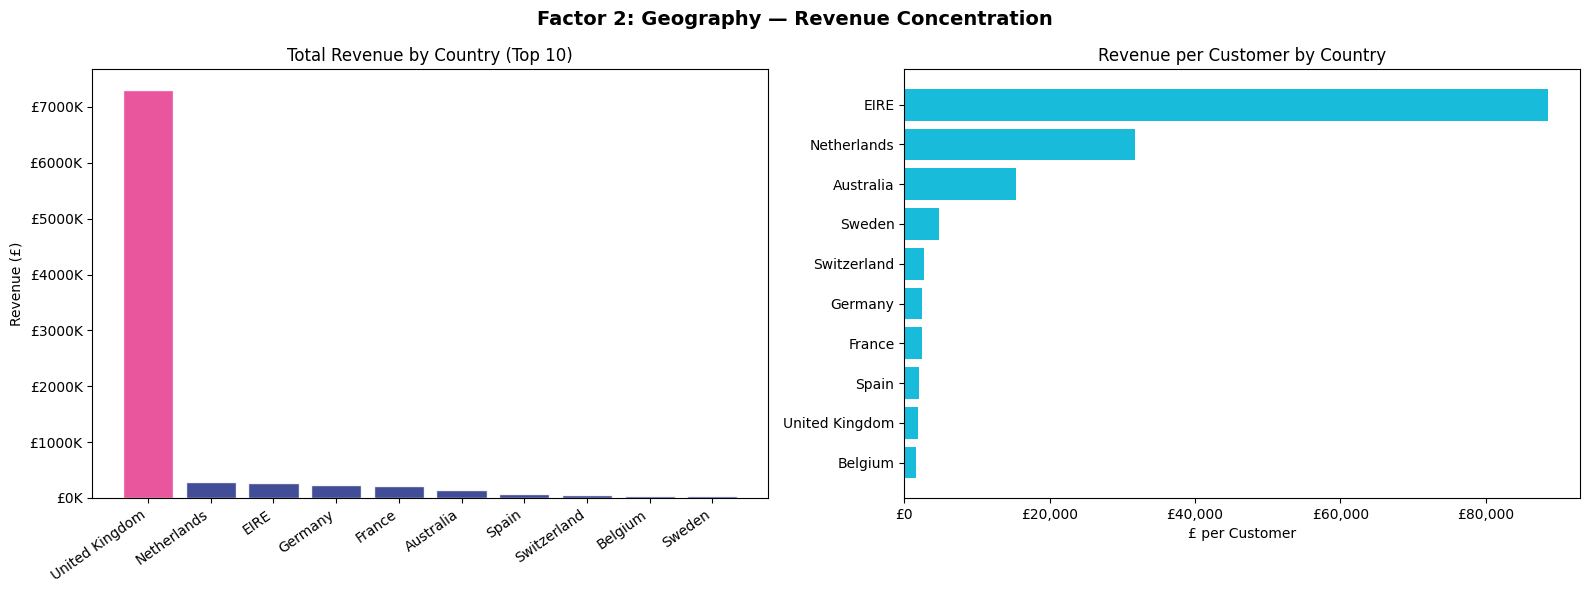

In [56]:
country_stats = df.groupby('Country').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Customers=('CustomerID', 'nunique')
).sort_values('Revenue', ascending=False).head(10)

country_stats['Rev_per_Customer'] = country_stats['Revenue'] / country_stats['Customers']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total revenue by country
colors = ['#E84393' if i == 0 else '#2D3A8C' for i in range(len(country_stats))]
axes[0].bar(country_stats.index, country_stats['Revenue'], color=colors, alpha=0.9, edgecolor='white')
axes[0].set_xticklabels(country_stats.index, rotation=35, ha='right')
axes[0].set_title('Total Revenue by Country (Top 10)')
axes[0].set_ylabel('Revenue (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

# Revenue per customer
rpc = country_stats['Rev_per_Customer'].sort_values()
axes[1].barh(rpc.index, rpc.values, color='#00B4D8', alpha=0.9)
axes[1].set_title('Revenue per Customer by Country')
axes[1].set_xlabel('£ per Customer')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.suptitle('Factor 2: Geography — Revenue Concentration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

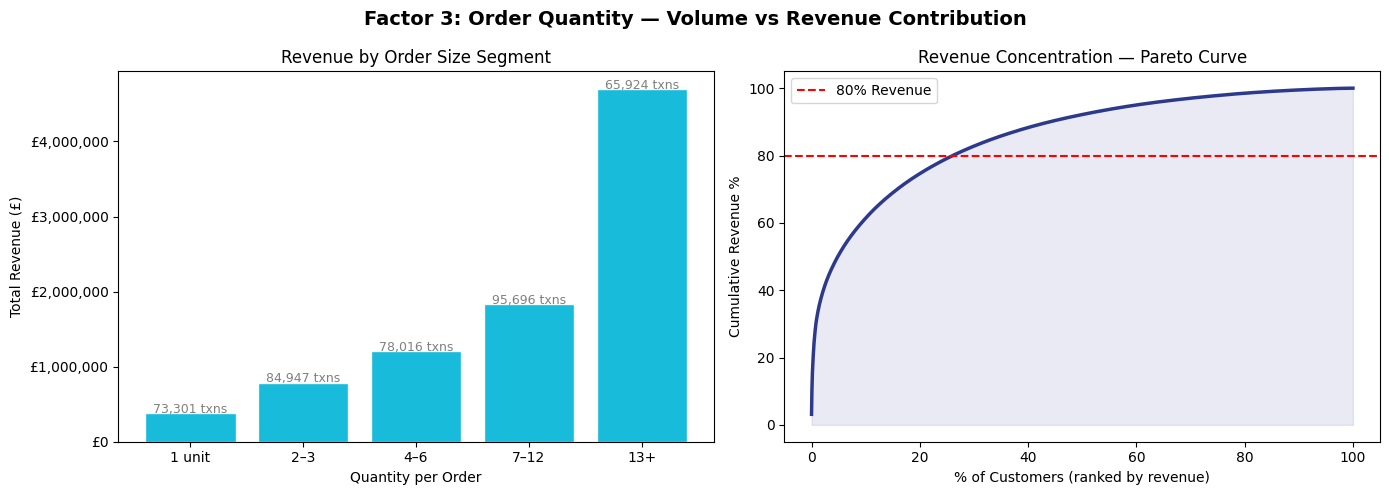

In [62]:
df['QuantityBin'] = pd.cut(df['Quantity'],
                            bins=[0, 1, 3, 6, 12, df['Quantity'].max()],
                            labels=['1 unit', '2–3', '4–6', '7–12', '13+'])

qty_seg = df.groupby('QuantityBin', observed=True).agg(
    Total_Revenue=('Revenue', 'sum'),
    Avg_Unit_Price=('UnitPrice', 'mean'),
    Num_Transactions=('InvoiceNo', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(qty_seg['QuantityBin'].astype(str), qty_seg['Total_Revenue'],
            color='#00B4D8', edgecolor='white', alpha=0.9)
for i, (rev, cnt) in enumerate(zip(qty_seg['Total_Revenue'], qty_seg['Num_Transactions'])):
    axes[0].text(i, rev + 500, f'{cnt:,} txns', ha='center', fontsize=9, color='gray')
axes[0].set_title('Revenue by Order Size Segment')
axes[0].set_xlabel('Quantity per Order')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Pareto curve — customer revenue concentration
cust_rev = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
cum_pct  = cust_rev.cumsum() / cust_rev.sum() * 100
x_pct    = np.linspace(0, 100, len(cum_pct))
axes[1].plot(x_pct, cum_pct.values, color='#2D3A8C', linewidth=2.5)
axes[1].axhline(80, color='red', linestyle='--', linewidth=1.5, label='80% Revenue')
axes[1].fill_between(x_pct, cum_pct.values, alpha=0.1, color='#2D3A8C')
axes[1].set_title('Revenue Concentration — Pareto Curve')
axes[1].set_xlabel('% of Customers (ranked by revenue)')
axes[1].set_ylabel('Cumulative Revenue %')
axes[1].legend()

plt.suptitle('Factor 3: Order Quantity — Volume vs Revenue Contribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

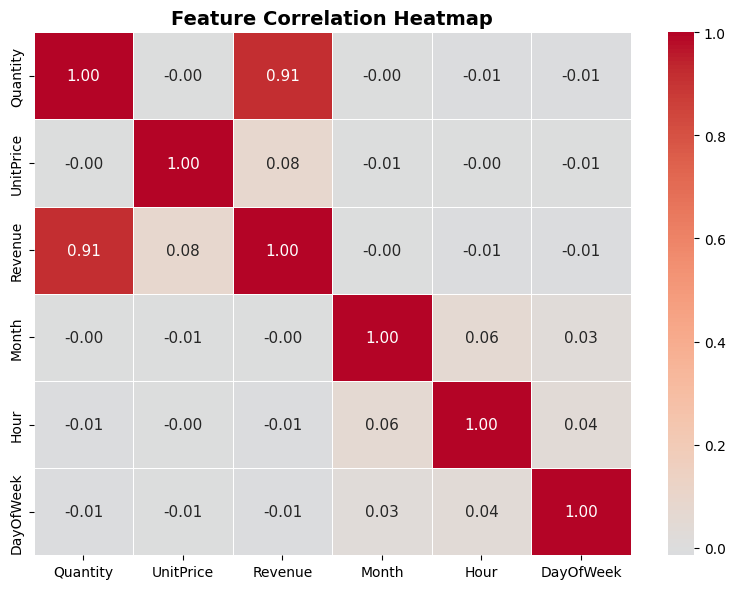

In [63]:
corr_features = df[['Quantity', 'UnitPrice', 'Revenue', 'Month', 'Hour', 'DayOfWeek']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_features, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 11})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [64]:
print("=" * 55)
print("   TOP 3 REVENUE-DRIVING FACTORS — SUMMARY")
print("=" * 55)

print("\n🥇 FACTOR 1: Product / Description")
print(f"   Top product by revenue : {cat_rev.index[0]}")
print(f"   Revenue contribution   : £{cat_rev['Total_Revenue'].iloc[0]:,.2f}")
print(f"   Insight: A small number of products drive a")
print(f"   disproportionate share of total revenue.")

print("\n🥈 FACTOR 2: Country / Geography")
print(f"   Top country            : {country_stats.index[0]}")
uk_share = country_stats['Revenue'].iloc[0] / df['Revenue'].sum() * 100
print(f"   Revenue share          : {uk_share:.1f}% of total")
print(f"   Insight: Geographic concentration is extreme —")
print(f"   one country dominates. Expansion = big opportunity.")

print("\n🥉 FACTOR 3: Quantity per Order")
bulk = qty_seg[qty_seg['QuantityBin'].astype(str).isin(['7–12', '13+'])]['Total_Revenue'].sum()
bulk_pct = bulk / df['Revenue'].sum() * 100
print(f"   Bulk order revenue     : £{bulk:,.2f} ({bulk_pct:.1f}% of total)")
print(f"   Insight: Encouraging bulk purchases via discounts")
print(f"   or bundles can significantly lift revenue.")

print("\n" + "=" * 55)

   TOP 3 REVENUE-DRIVING FACTORS — SUMMARY

🥇 FACTOR 1: Product / Description
   Top product by revenue : PAPER CRAFT , LITTLE BIRDIE
   Revenue contribution   : £168,469.60
   Insight: A small number of products drive a
   disproportionate share of total revenue.

🥈 FACTOR 2: Country / Geography
   Top country            : United Kingdom
   Revenue share          : 82.0% of total
   Insight: Geographic concentration is extreme —
   one country dominates. Expansion = big opportunity.

🥉 FACTOR 3: Quantity per Order
   Bulk order revenue     : £6,531,954.76 (73.3% of total)
   Insight: Encouraging bulk purchases via discounts
   or bundles can significantly lift revenue.



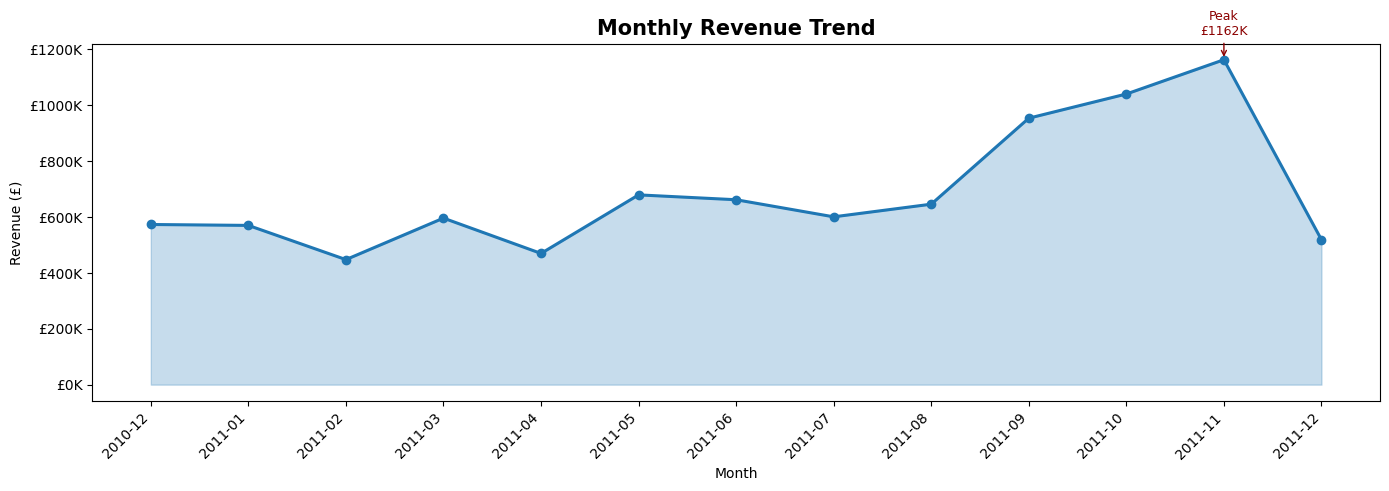

In [65]:
monthly = (df.groupby("YearMonth")["Revenue"]
             .sum()
             .reset_index()
             .sort_values("YearMonth"))
monthly["YearMonth_str"] = monthly["YearMonth"].astype(str)
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly["YearMonth_str"], monthly["Revenue"],
                alpha=0.25, color="#1f77b4")
ax.plot(monthly["YearMonth_str"], monthly["Revenue"],
        marker="o", linewidth=2.2, color="#1f77b4", markersize=6)
 
# Annotate peak
peak_idx = monthly["Revenue"].idxmax()
ax.annotate(f'Peak\n£{monthly.loc[peak_idx,"Revenue"]/1e3:.0f}K',
            xy=(monthly.loc[peak_idx,"YearMonth_str"],
                monthly.loc[peak_idx,"Revenue"]),
            xytext=(0, 18), textcoords="offset points",
            ha="center", fontsize=9, color="darkred",
            arrowprops=dict(arrowstyle="->", color="darkred"))
 
ax.set_title("Monthly Revenue Trend", fontsize=15, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e3:.0f}K"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("monthly_revenue_trend.png", bbox_inches="tight")
plt.show()

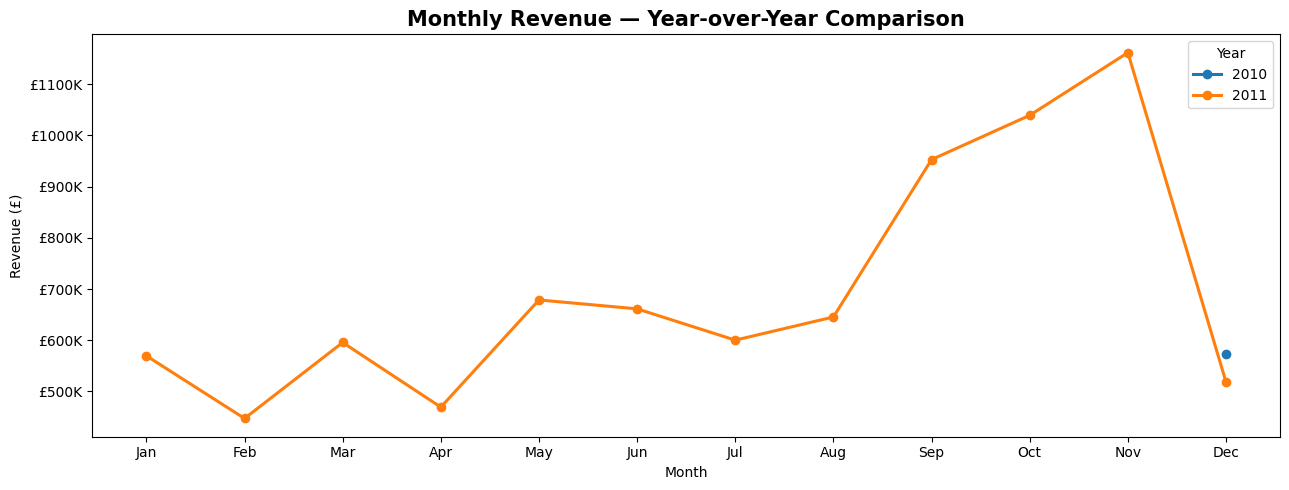

In [66]:
monthly_yr = (df.groupby(["Year", "Month"])["Revenue"]
                .sum()
                .reset_index())
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
 
fig, ax = plt.subplots(figsize=(13, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for i, yr in enumerate(sorted(monthly_yr["Year"].unique())):
    sub = monthly_yr[monthly_yr["Year"] == yr].sort_values("Month")
    ax.plot(sub["Month"], sub["Revenue"],
            marker="o", linewidth=2.2, label=str(yr),
            color=colors[i % len(colors)])
 
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("Monthly Revenue — Year-over-Year Comparison", fontsize=15, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e3:.0f}K"))
ax.legend(title="Year")
plt.tight_layout()
plt.savefig("yoy_monthly_revenue.png", bbox_inches="tight")
plt.show()

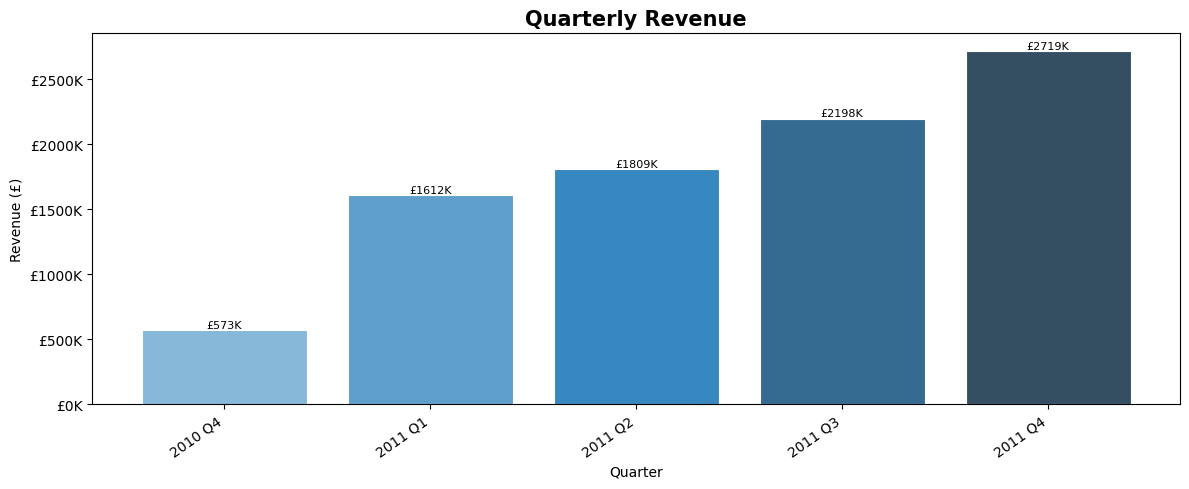

In [67]:
quarterly = (df.groupby(["Year", "Quarter"])["Revenue"]
               .sum()
               .reset_index())
quarterly["Q_Label"] = quarterly["Year"].astype(str) + " Q" + quarterly["Quarter"].astype(str)
 
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(quarterly["Q_Label"], quarterly["Revenue"],
              color=sns.color_palette("Blues_d", len(quarterly)),
              edgecolor="white", linewidth=0.8)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 2000,
            f"£{h/1e3:.0f}K", ha="center", va="bottom", fontsize=8)
 
ax.set_title("Quarterly Revenue", fontsize=15, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e3:.0f}K"))
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("quarterly_revenue.png", bbox_inches="tight")
plt.show()

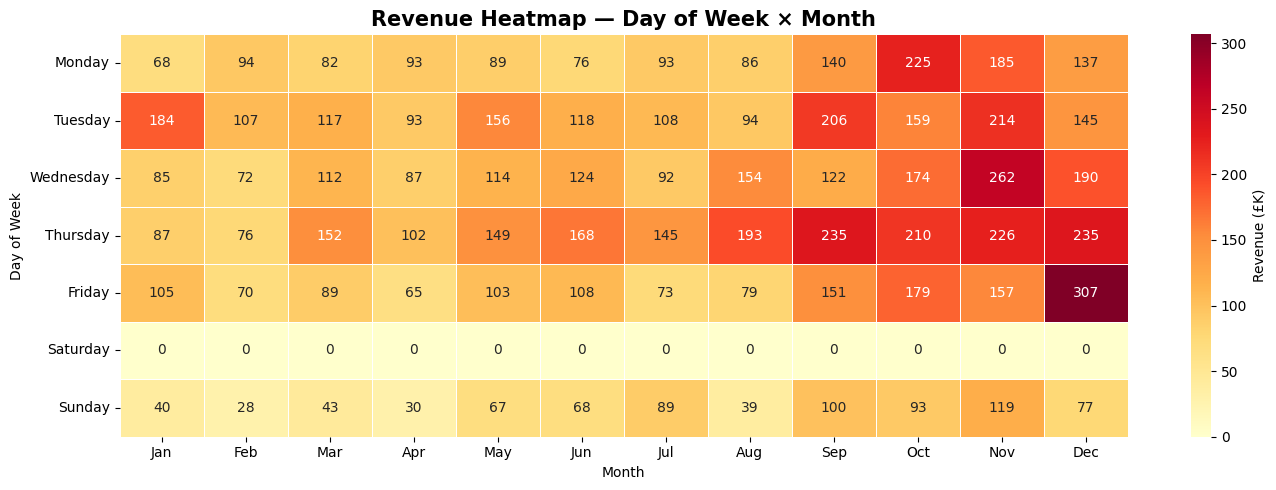

In [70]:
# ── CELL 6: Day-of-Week Revenue Heatmap ──────────────────────
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

# Fix: map integer DayOfWeek → name (works whether column is int or string)
day_map = {0:"Monday",1:"Tuesday",2:"Wednesday",3:"Thursday",
           4:"Friday",5:"Saturday",6:"Sunday"}
df["DayOfWeek"] = df["DayOfWeek"].map(day_map) if df["DayOfWeek"].dtype != object else df["DayOfWeek"]

dow_month = (df.groupby(["DayOfWeek", "Month"])["Revenue"]
               .sum()
               .unstack(fill_value=0))

# Reindex rows to correct day order, fill any missing days with 0
dow_month = dow_month.reindex(dow_order, fill_value=0)

# Reindex columns to all 12 months, fill missing months with 0
dow_month = dow_month.reindex(range(1, 13), axis=1, fill_value=0)
dow_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(dow_month / 1e3, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Revenue (£K)"})
ax.set_title("Revenue Heatmap — Day of Week × Month", fontsize=15, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.savefig("dow_month_heatmap.png", bbox_inches="tight")
plt.show()

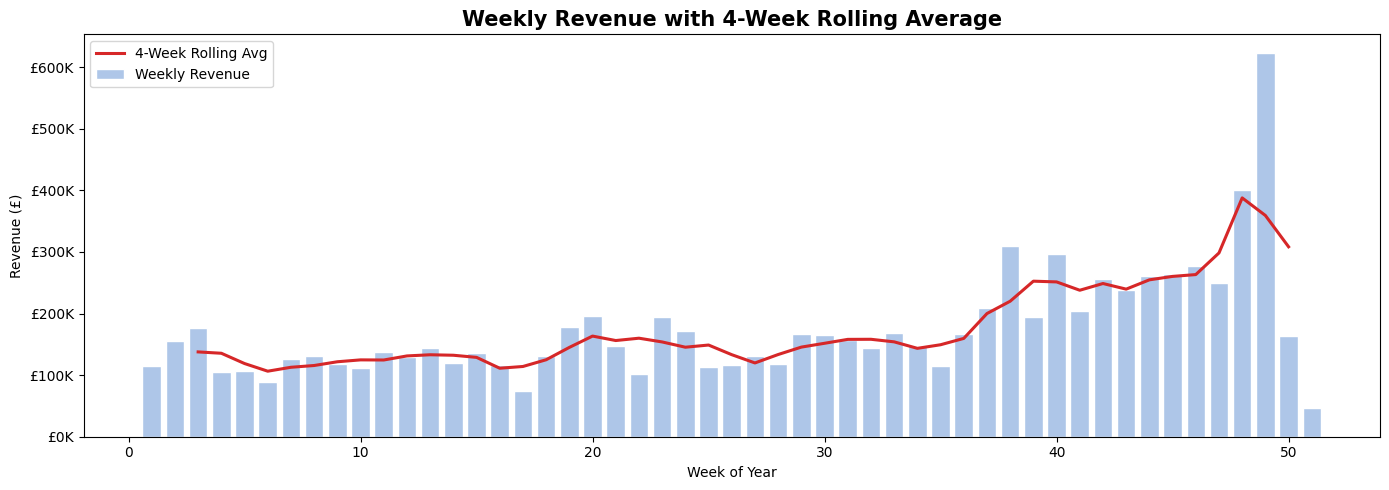

In [71]:
weekly = (df.groupby("Week")["Revenue"]
            .sum()
            .reset_index()
            .sort_values("Week"))
weekly["Rolling4"] = weekly["Revenue"].rolling(4, center=True).mean()
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(weekly["Week"], weekly["Revenue"],
       color="#aec6e8", edgecolor="white", label="Weekly Revenue")
ax.plot(weekly["Week"], weekly["Rolling4"],
        color="#d62728", linewidth=2.2, label="4-Week Rolling Avg")
 
ax.set_title("Weekly Revenue with 4-Week Rolling Average", fontsize=15, fontweight="bold")
ax.set_xlabel("Week of Year")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e3:.0f}K"))
ax.legend()
plt.tight_layout()
plt.savefig("weekly_rolling_avg.png", bbox_inches="tight")
plt.show()

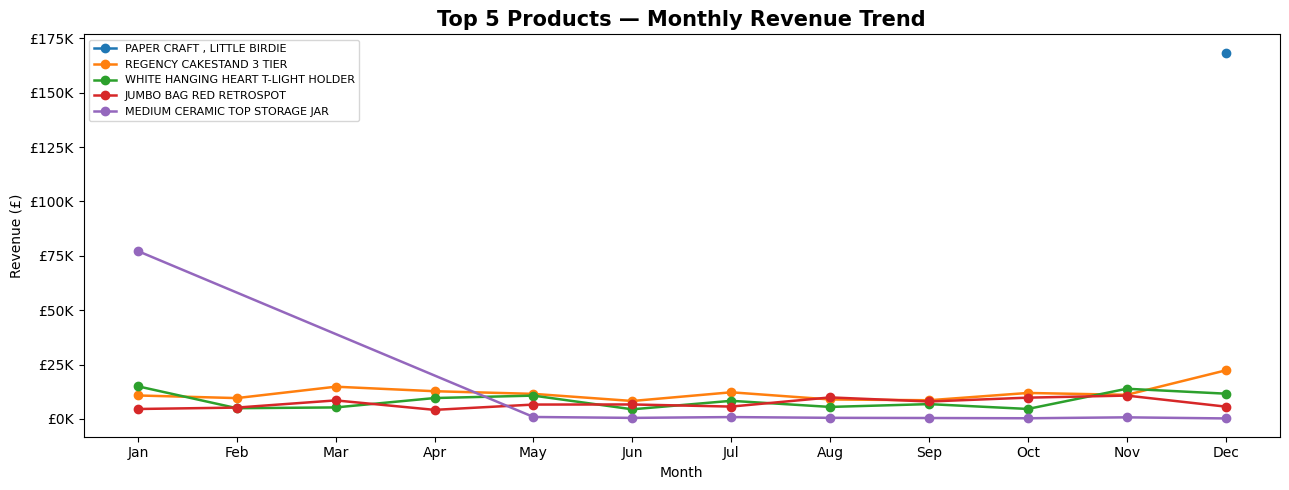

In [72]:
top5 = (df.groupby("Description")["Revenue"]
          .sum()
          .nlargest(5)
          .index.tolist())
 
prod_monthly = (df[df["Description"].isin(top5)]
                  .groupby(["Description", "Month"])["Revenue"]
                  .sum()
                  .reset_index())
 
fig, ax = plt.subplots(figsize=(13, 5))
for prod in top5:
    sub = prod_monthly[prod_monthly["Description"] == prod].sort_values("Month")
    ax.plot(sub["Month"], sub["Revenue"],
            marker="o", linewidth=1.8,
            label=prod[:35] + ("…" if len(prod) > 35 else ""))
 
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("Top 5 Products — Monthly Revenue Trend", fontsize=15, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e3:.0f}K"))
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("top5_products_monthly.png", bbox_inches="tight")
plt.show()

In [73]:
season_map = {12:"Winter", 1:"Winter", 2:"Winter",
              3:"Spring",  4:"Spring",  5:"Spring",
              6:"Summer",  7:"Summer",  8:"Summer",
              9:"Autumn", 10:"Autumn", 11:"Autumn"}
 
df["Season"] = df["Month"].map(season_map)
season_stats = (df.groupby("Season")
                  .agg(Total_Revenue=("Revenue","sum"),
                       Num_Orders=("InvoiceNo","nunique"),
                       Avg_Order_Value=("Revenue","mean"))
                  .reindex(["Spring","Summer","Autumn","Winter"])
                  .reset_index())
season_stats["Revenue_Share_%"] = (
    season_stats["Total_Revenue"] / season_stats["Total_Revenue"].sum() * 100
).round(1)
season_stats["Total_Revenue"] = season_stats["Total_Revenue"].map("£{:,.0f}".format)
season_stats["Avg_Order_Value"] = season_stats["Avg_Order_Value"].map("£{:.2f}".format)
 
print("\n========= SEASONAL SUMMARY =========")
print(season_stats.to_string(index=False))


========= SEASONAL SUMMARY =========
Season Total_Revenue  Num_Orders Avg_Order_Value  Revenue_Share_%
Spring    £1,743,296        4025          £22.31             19.6
Summer    £1,906,649        4004          £23.53             21.4
Autumn    £3,153,975        6341          £20.47             35.4
Winter    £2,107,489        4162          £24.91             23.6


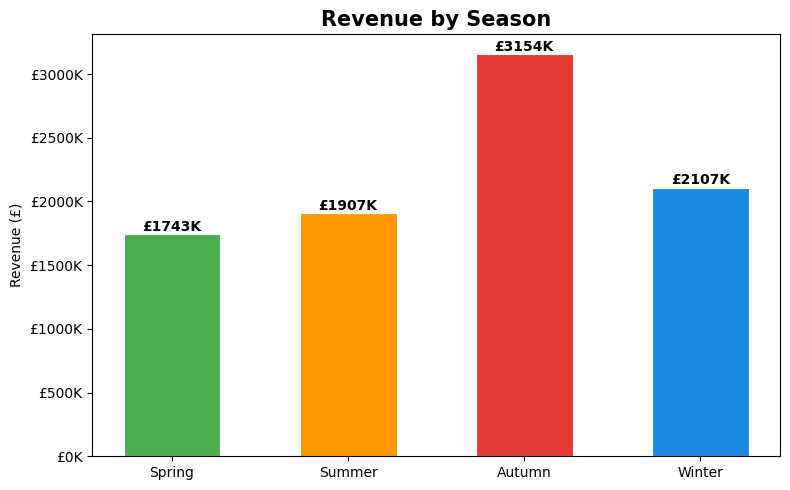


 All seasonal trend charts saved as PNG files.


In [90]:
season_rev = (df.groupby("Season")["Revenue"]
                .sum()
                .reindex(["Spring","Summer","Autumn","Winter"])
                .reset_index())
colors_s = ["#4caf50","#ff9800","#e53935","#1e88e5"]
 
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(season_rev["Season"], season_rev["Revenue"],
              color=colors_s, edgecolor="white", linewidth=0.8, width=0.55)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 3000,
            f"£{h/1e3:.0f}K", ha="center", va="bottom", fontsize=10, fontweight="bold")
 
ax.set_title("Revenue by Season", fontsize=15, fontweight="bold")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e3:.0f}K"))
plt.tight_layout()
plt.savefig("seasonal_revenue.png", bbox_inches="tight")
plt.show()
 
print("\n All seasonal trend charts saved as PNG files.")

In [75]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV

In [76]:
SNAPSHOT_DATE   = df["InvoiceDate"].max()
CUTOFF_DATE     = SNAPSHOT_DATE - pd.Timedelta(days=90)
 
obs_df  = df[df["InvoiceDate"] <= CUTOFF_DATE]   # feature window
pred_df = df[df["InvoiceDate"] >  CUTOFF_DATE]   # target window
 
print(f"\nObservation window : up to {CUTOFF_DATE.date()}")
print(f"Prediction window  : {CUTOFF_DATE.date()} → {SNAPSHOT_DATE.date()} (90 days)")
print(f"Customers in obs   : {obs_df['CustomerID'].nunique():,}")
print(f"Customers in pred  : {pred_df['CustomerID'].nunique():,}")


Observation window : up to 2011-09-10
Prediction window  : 2011-09-10 → 2011-12-09 (90 days)
Customers in obs   : 3,370
Customers in pred  : 2,889


In [77]:
ref_date = CUTOFF_DATE + pd.Timedelta(days=1)   # recency reference
 
rfm = obs_df.groupby("CustomerID").agg(
    Recency        = ("InvoiceDate",  lambda x: (ref_date - x.max()).days),
    Frequency      = ("InvoiceNo",    "nunique"),
    Monetary       = ("Revenue",      "sum"),
    AvgOrderValue  = ("Revenue",      "mean"),
    TotalItems     = ("Quantity",     "sum"),
    UniqueProducts = ("Description",  "nunique"),
    UniqueMonths   = ("InvoiceDate",  lambda x: x.dt.to_period("M").nunique()),
    LastOrderValue = ("Revenue",      "last"),
    StdOrderValue  = ("Revenue",      "std"),
).reset_index()
 
# Purchase gap (avg days between orders)
gaps = (obs_df.sort_values("InvoiceDate")
              .groupby("CustomerID")["InvoiceDate"]
              .apply(lambda x: x.diff().dt.days.mean()))
rfm = rfm.merge(gaps.rename("AvgDaysBetweenOrders"), on="CustomerID", how="left")
 
# Fill NaN std / gap for single-order customers
rfm["StdOrderValue"].fillna(0, inplace=True)
rfm["AvgDaysBetweenOrders"].fillna(rfm["Recency"], inplace=True)   # only 1 order → gap = recency
 
# Target: did this customer purchase in the prediction window?
repeat_buyers = set(pred_df["CustomerID"].unique())
rfm["Target"] = rfm["CustomerID"].isin(repeat_buyers).astype(int)
 
print(f"\nFeature matrix shape : {rfm.shape}")
print(f"Class balance:")
print(rfm["Target"].value_counts(normalize=True).rename({0:"No purchase",1:"Purchased"}).to_string())


Feature matrix shape : (3370, 12)
Class balance:
Target
Purchased      0.57003
No purchase    0.42997


In [78]:
FEATURES = ["Recency", "Frequency", "Monetary", "AvgOrderValue",
            "TotalItems", "UniqueProducts", "UniqueMonths",
            "LastOrderValue", "StdOrderValue", "AvgDaysBetweenOrders"]
 
X = rfm[FEATURES]
y = rfm["Target"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
 
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

Train: 2,696  |  Test: 674


In [79]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                          random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                               max_depth=4, random_state=42))
    ])
}
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
 
print(f"\n{'Model':<25} {'CV ROC-AUC':>12} {'Test ROC-AUC':>13}")
print("-" * 52)
for name, pipe in models.items():
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring="roc_auc", n_jobs=-1)
    pipe.fit(X_train, y_train)
    y_prob  = pipe.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    results[name] = {"pipe": pipe, "y_prob": y_prob, "test_auc": test_auc,
                     "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()}
    print(f"{name:<25} {cv_scores.mean():.4f} ± {cv_scores.std():.4f}   {test_auc:.4f}")


Model                       CV ROC-AUC  Test ROC-AUC
----------------------------------------------------
Logistic Regression       0.7496 ± 0.0137   0.7372
Random Forest             0.7209 ± 0.0142   0.7354
Gradient Boosting         0.7307 ± 0.0101   0.7305


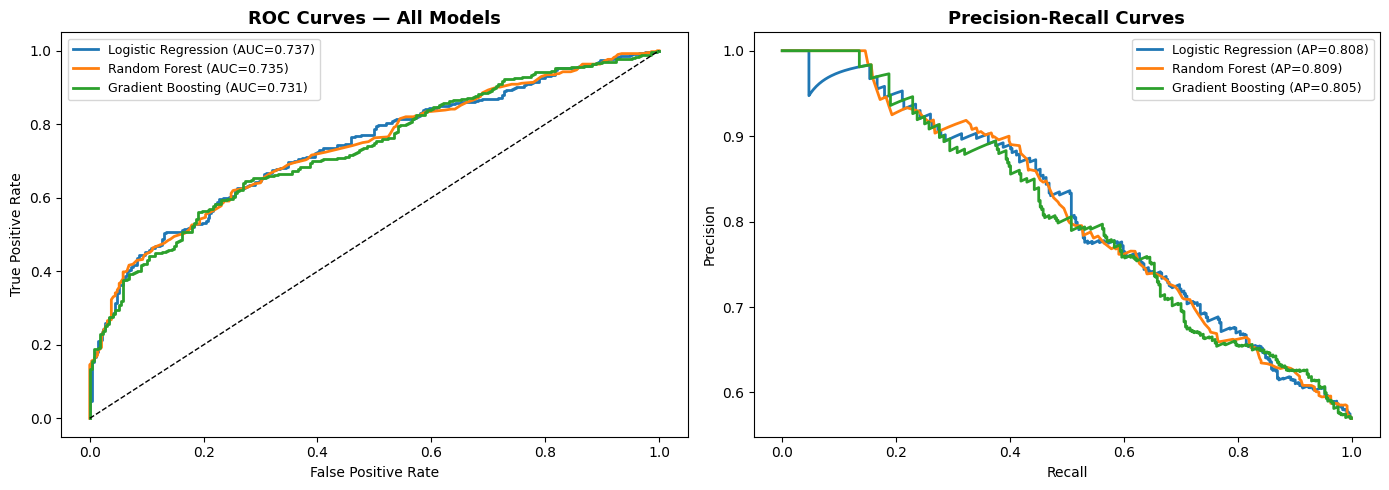

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
 
# ROC curves
ax = axes[0]
for (name, res), col in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['test_auc']:.3f})", color=col, lw=2)
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9)
 
# Precision-Recall curves
ax = axes[1]
for (name, res), col in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    ap = average_precision_score(y_test, res["y_prob"])
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=col, lw=2)
ax.set_title("Precision-Recall Curves", fontsize=13, fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("roc_pr_curves.png", bbox_inches="tight")
plt.show()


 Best Model: Logistic Regression  (Test AUC = 0.7372)

               precision    recall  f1-score   support

  No Purchase       0.57      0.79      0.66       290
Will Purchase       0.78      0.56      0.65       384

     accuracy                           0.66       674
    macro avg       0.67      0.67      0.66       674
 weighted avg       0.69      0.66      0.65       674



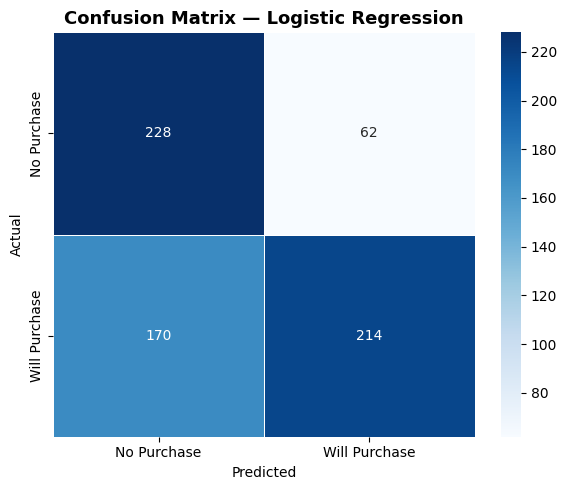

In [89]:
best_name = max(results, key=lambda n: results[n]["test_auc"])
best      = results[best_name]
print(f"\n Best Model: {best_name}  (Test AUC = {best['test_auc']:.4f})\n")
 
y_pred = best["pipe"].predict(X_test)
print(classification_report(y_test, y_pred, target_names=["No Purchase", "Will Purchase"]))
 
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Purchase","Will Purchase"],
            yticklabels=["No Purchase","Will Purchase"],
            linewidths=0.5, ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

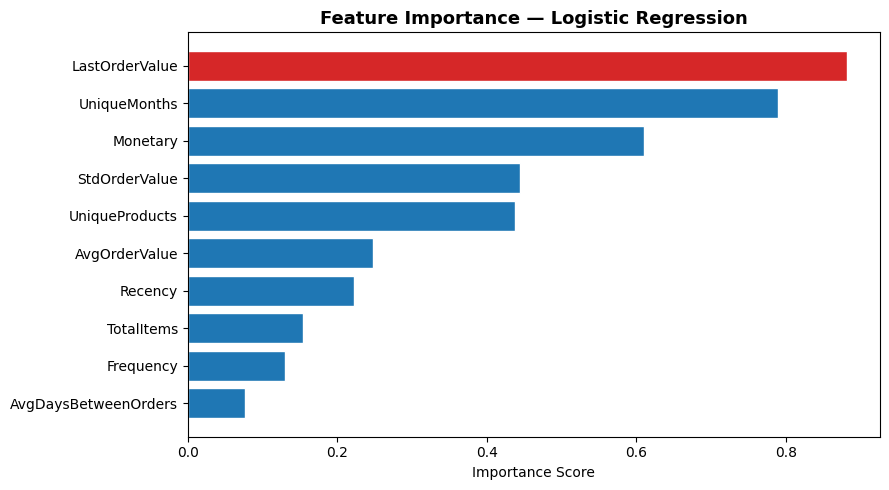

In [83]:
if "Random Forest" in best_name or "Gradient" in best_name:
    clf        = best["pipe"].named_steps["clf"]
    importance = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
else:
    # Logistic Regression coefficients
    scaler = best["pipe"].named_steps["scaler"]
    clf    = best["pipe"].named_steps["clf"]
    importance = pd.Series(np.abs(clf.coef_[0]), index=FEATURES).sort_values()
 
fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ["#d62728" if v == importance.max() else "#1f77b4" for v in importance]
ax.barh(importance.index, importance.values, color=colors_imp, edgecolor="white")
ax.set_title(f"Feature Importance — {best_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()


In [85]:
rfm["PurchaseProbability"] = best["pipe"].predict_proba(rfm[FEATURES])[:, 1]
 
# Segment into risk tiers
def segment(p):
    if p >= 0.70: return " High Likelihood"
    if p >= 0.40: return "  Needs Nurturing"
    return "  At Risk / Churned"
 
rfm["Segment"] = rfm["PurchaseProbability"].apply(segment)
 
seg_summary = (rfm.groupby("Segment")
                  .agg(Customers        = ("CustomerID",          "count"),
                       Avg_Probability  = ("PurchaseProbability", "mean"),
                       Avg_Monetary     = ("Monetary",            "mean"),
                       Avg_Recency_days = ("Recency",             "mean"))
                  .reset_index()
                  .sort_values("Avg_Probability", ascending=False))
 
print("\n========= CUSTOMER SEGMENT SUMMARY =========")
print(seg_summary.to_string(index=False))


========= CUSTOMER SEGMENT SUMMARY =========
            Segment  Customers  Avg_Probability  Avg_Monetary  Avg_Recency_days
    High Likelihood        780         0.859619   4813.205179         30.221795
    Needs Nurturing       1180         0.529280    896.883680         66.885593
  At Risk / Churned       1410         0.305710    455.874043        155.524113


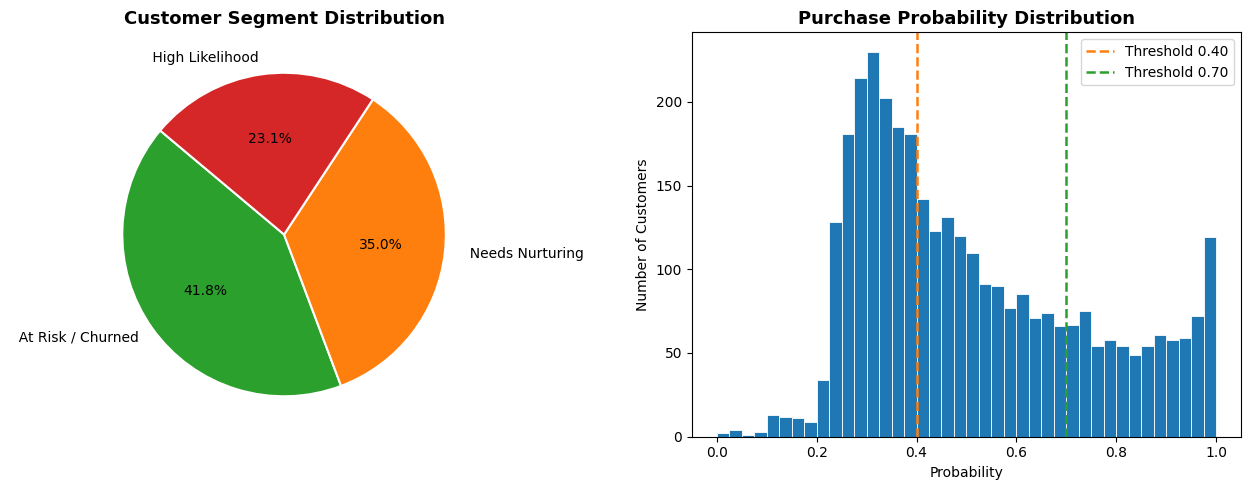

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Count per segment
seg_counts = rfm["Segment"].value_counts()
colors_seg = ["#2ca02c", "#ff7f0e", "#d62728"]
axes[0].pie(seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
            colors=colors_seg, startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Customer Segment Distribution", fontsize=13, fontweight="bold")
 
# Probability distribution
axes[1].hist(rfm["PurchaseProbability"], bins=40, color="#1f77b4",
             edgecolor="white", linewidth=0.6)
axes[1].axvline(0.40, color="#ff7f0e", linestyle="--", lw=1.8, label="Threshold 0.40")
axes[1].axvline(0.70, color="#2ca02c", linestyle="--", lw=1.8, label="Threshold 0.70")
axes[1].set_title("Purchase Probability Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Probability")
axes[1].set_ylabel("Number of Customers")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("segment_distribution.png", bbox_inches="tight")
plt.show()

In [88]:
output = rfm[["CustomerID", "Recency", "Frequency", "Monetary",
              "PurchaseProbability", "Segment"]].sort_values(
              "PurchaseProbability", ascending=False)
 
output.to_csv("customer_purchase_scores.csv", index=False)
print("\n Scored customer list saved → customer_purchase_scores.csv")
print(f"\nTop 10 customers most likely to purchase next:")
print(output.head(10).to_string(index=False))


 Scored customer list saved → customer_purchase_scores.csv

Top 10 customers most likely to purchase next:
 CustomerID  Recency  Frequency  Monetary  PurchaseProbability          Segment
    14911.0        3        112  81977.68             1.000000  High Likelihood
    14646.0        3         42 178302.62             1.000000  High Likelihood
    14156.0        3         42  98858.34             1.000000  High Likelihood
    12748.0        1        132  14107.75             0.999999  High Likelihood
    18102.0        9         27 135450.75             0.999998  High Likelihood
    17841.0        2         81  23501.86             0.999998  High Likelihood
    12415.0        9         15 102087.88             0.999991  High Likelihood
    13089.0       10         71  43324.49             0.999980  High Likelihood
    15311.0        4         65  46155.48             0.999965  High Likelihood
    14298.0        9         37  41182.51             0.999959  High Likelihood


In [91]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist
import matplotlib.patches as mpatches
 
print("✅ Clustering imports done.")

✅ Clustering imports done.


In [92]:
# Use RFM + purchase probability 
CLUSTER_FEATURES = ["Recency", "Frequency", "Monetary",
                    "AvgOrderValue", "UniqueProducts",
                    "UniqueMonths", "PurchaseProbability"]
 
X_clust = rfm[CLUSTER_FEATURES].copy()
 
# Log-transform skewed monetary/frequency columns
for col in ["Frequency", "Monetary", "AvgOrderValue", "UniqueProducts"]:
    X_clust[col] = np.log1p(X_clust[col])
 
scaler_clust = StandardScaler()
X_scaled     = scaler_clust.fit_transform(X_clust)
 
print(f"Clustering matrix: {X_scaled.shape}")

Clustering matrix: (3370, 7)


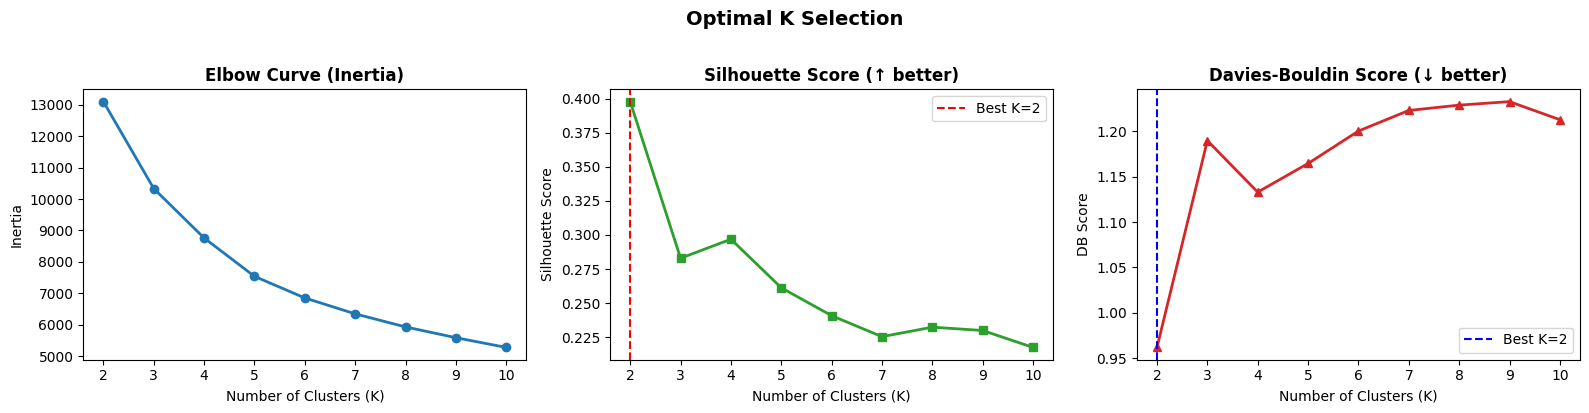


Best K by Silhouette  : 2
Best K by Davies-Bouldin: 2


In [93]:
K_range    = range(2, 11)
inertias   = []
sil_scores = []
db_scores  = []
 
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=15,
                random_state=42, max_iter=500)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=3000, random_state=42))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
# Elbow
axes[0].plot(K_range, inertias, marker="o", color="#1f77b4", lw=2)
axes[0].set_title("Elbow Curve (Inertia)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
 
# Silhouette
axes[1].plot(K_range, sil_scores, marker="s", color="#2ca02c", lw=2)
best_sil_k = K_range[np.argmax(sil_scores)]
axes[1].axvline(best_sil_k, color="red", linestyle="--", lw=1.5,
                label=f"Best K={best_sil_k}")
axes[1].set_title("Silhouette Score (↑ better)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
 
# Davies-Bouldin
axes[2].plot(K_range, db_scores, marker="^", color="#d62728", lw=2)
best_db_k = K_range[np.argmin(db_scores)]
axes[2].axvline(best_db_k, color="blue", linestyle="--", lw=1.5,
                label=f"Best K={best_db_k}")
axes[2].set_title("Davies-Bouldin Score (↓ better)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Number of Clusters (K)")
axes[2].set_ylabel("DB Score")
axes[2].legend()
 
plt.suptitle("Optimal K Selection", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("optimal_k_selection.png", bbox_inches="tight")
plt.show()
 
print(f"\nBest K by Silhouette  : {best_sil_k}")
print(f"Best K by Davies-Bouldin: {best_db_k}")

In [98]:
profile = rfm.groupby("Cluster").agg(
    Customers          = ("CustomerID",          "count"),
    Avg_Recency        = ("Recency",              "mean"),
    Avg_Frequency      = ("Frequency",            "mean"),
    Avg_Monetary       = ("Monetary",             "mean"),
    Avg_OrderValue     = ("AvgOrderValue",         "mean"),
    Avg_UniqueProducts = ("UniqueProducts",        "mean"),
    Avg_PurchaseProb   = ("PurchaseProbability",  "mean"),
).round(2)
 
# Auto-label clusters based on RFM characteristics
def label_cluster(row):
    if row["Avg_PurchaseProb"] >= 0.65 and row["Avg_Frequency"] >= 5:
        return " Champions"
    elif row["Avg_PurchaseProb"] >= 0.50:
        return " Loyal Customers"
    elif row["Avg_Recency"] <= 60 and row["Avg_Frequency"] <= 3:
        return " New / Promising"
    elif row["Avg_Recency"] >= 150 and row["Avg_PurchaseProb"] < 0.30:
        return "  Lost / Churned"
    elif row["Avg_Monetary"] >= profile["Avg_Monetary"].median() * 1.5:
        return " High Spenders"
    else:
        return "  At Risk"
 
profile["Persona"] = profile.apply(label_cluster, axis=1)
print("\n========= CLUSTER PROFILES =========")
print(profile.to_string())
 
# Map persona back to rfm
rfm["Persona"] = rfm["Cluster"].map(profile["Persona"])


========= CLUSTER PROFILES =========
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_OrderValue  Avg_UniqueProducts  Avg_PurchaseProb           Persona
Cluster                                                                                                                             
0             3339        96.12           3.26       1161.04           32.06               48.11              0.51   Loyal Customers
1                7        38.29          37.43     108617.49        11269.53              421.71              0.86         Champions
2               24        23.71          31.17      34098.92          905.68              224.62              0.91         Champions


In [99]:
print(rfm.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
       'TotalItems', 'UniqueProducts', 'UniqueMonths', 'LastOrderValue',
       'StdOrderValue', 'AvgDaysBetweenOrders', 'Target',
       'PurchaseProbability', 'Segment', 'Cluster', 'Persona'],
      dtype='object')


In [100]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm[["Recency", "Frequency", "Monetary"]])

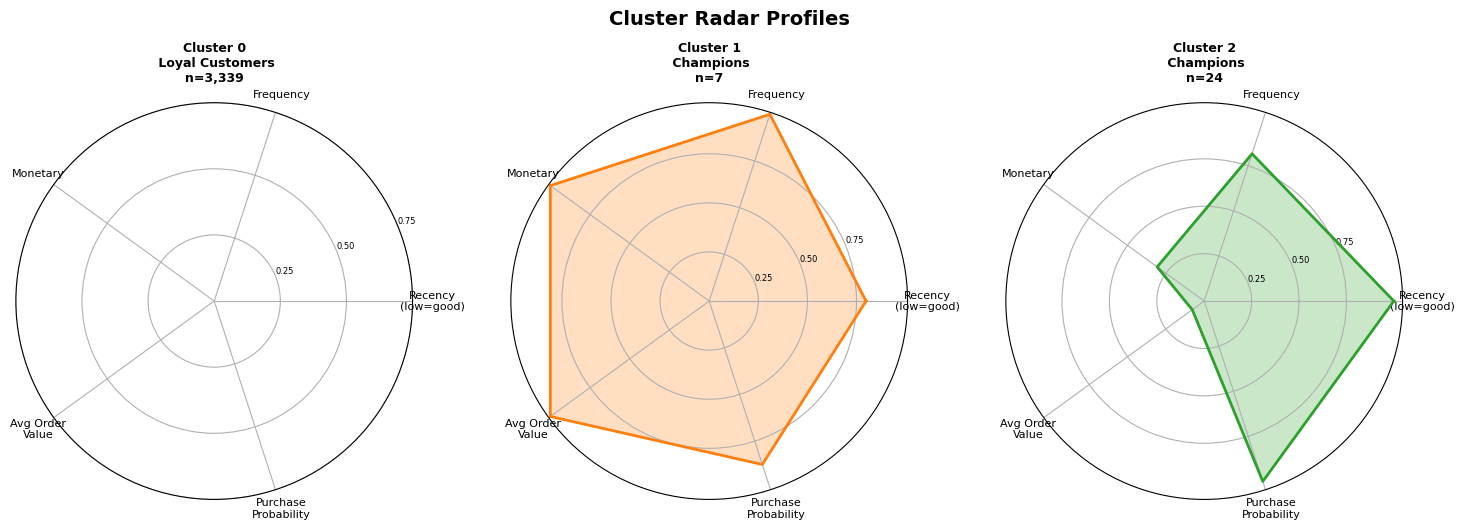

In [105]:
from matplotlib.patches import FancyArrowPatch
 
radar_features = ["Avg_Recency", "Avg_Frequency", "Avg_Monetary",
                  "Avg_OrderValue", "Avg_PurchaseProb"]
radar_labels   = ["Recency\n(low=good)", "Frequency", "Monetary",
                  "Avg Order\nValue", "Purchase\nProbability"]
 
# Normalize 0–1 per feature (recency inverted: lower = better)
radar_data = profile[radar_features].copy()
radar_data["Avg_Recency"] = 1 - (radar_data["Avg_Recency"] - radar_data["Avg_Recency"].min()) / \
                                 (radar_data["Avg_Recency"].max() - radar_data["Avg_Recency"].min() + 1e-9)
for col in radar_features[1:]:
    col_min, col_max = radar_data[col].min(), radar_data[col].max()
    radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min + 1e-9)
 
N      = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon
 
ncols  = min(OPTIMAL_K, 3)
nrows  = (OPTIMAL_K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows),
                          subplot_kw=dict(polar=True))
axes = np.array(axes).flatten()
 
palette = plt.cm.tab10.colors
for i, (idx, row) in enumerate(radar_data.iterrows()):
    ax     = axes[i]
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=palette[i], lw=2)
    ax.fill(angles, values, color=palette[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["0.25", "0.50", "0.75"], fontsize=6)
    ax.set_title(f"Cluster {idx}\n{profile.loc[idx,'Persona']}\n"
                 f"n={profile.loc[idx,'Customers']:,}",
                 fontsize=9, fontweight="bold", pad=15)
 
# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Cluster Radar Profiles", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("cluster_radar.png", bbox_inches="tight")
plt.show()

In [102]:
kmeans = KMeans(n_clusters=3, random_state=42)

In [104]:
OPTIMAL_K = 3

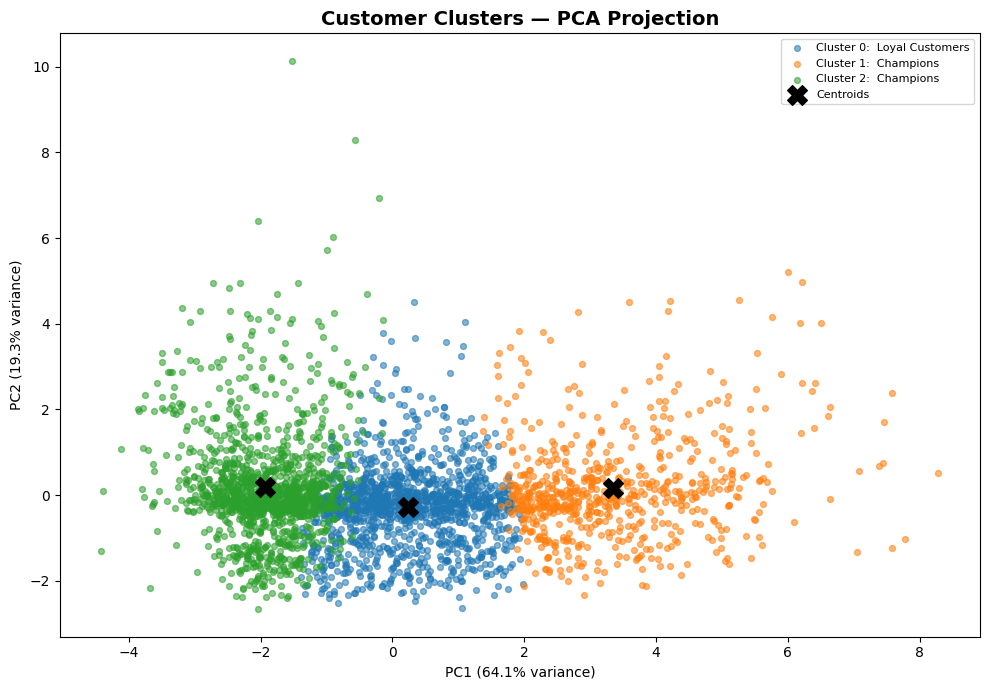

In [114]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: KMeans (make sure this exists) ---
OPTIMAL_K = rfm["Cluster"].nunique() if "Cluster" in rfm.columns else 3

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42)
rfm["Cluster"] = km_final.fit_predict(X_scaled)

# --- Step 2: PCA ---
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

rfm["PCA1"] = coords[:, 0]
rfm["PCA2"] = coords[:, 1]

# --- Step 3: Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

# fallback palette (in case not defined)
palette = plt.cm.tab10.colors

for c in sorted(rfm["Cluster"].unique()):
    mask = rfm["Cluster"] == c
    
    # safe persona handling
    persona = profile.loc[c, "Persona"] if "Persona" in profile.columns else f"Segment {c}"
    
    ax.scatter(
        rfm.loc[mask, "PCA1"],
        rfm.loc[mask, "PCA2"],
        s=18,
        alpha=0.55,
        color=palette[c % len(palette)],
        label=f"Cluster {c}: {persona}"
    )

# --- Step 4: Centroids ---
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=200,
    marker="X",
    color="black",
    zorder=5,
    label="Centroids"
)

# --- Step 5: Labels ---
ax.set_title("Customer Clusters — PCA Projection", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("cluster_pca_scatter.png", bbox_inches="tight")
plt.show()

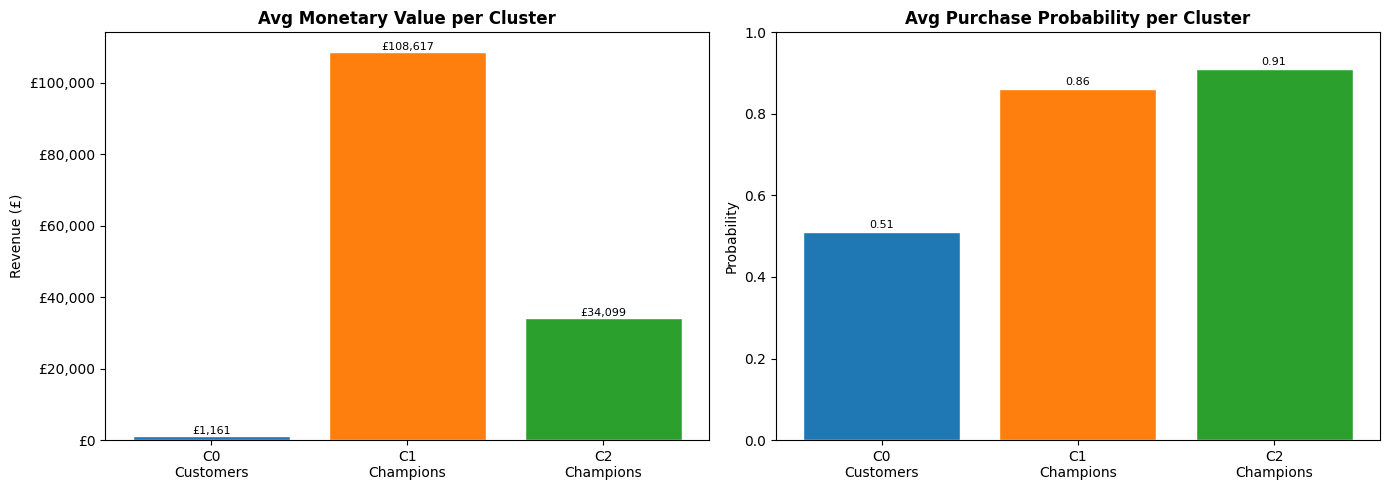

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
cluster_labels = [f"C{i}\n{profile.loc[i,'Persona'].split()[-1]}"
                  for i in sorted(rfm["Cluster"].unique())]
 
# Avg Monetary per cluster
avg_mon = [profile.loc[i, "Avg_Monetary"] for i in sorted(rfm["Cluster"].unique())]
bars = axes[0].bar(cluster_labels, avg_mon,
                   color=[palette[i] for i in sorted(rfm["Cluster"].unique())],
                   edgecolor="white")
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 5,
                 f"£{h:,.0f}", ha="center", va="bottom", fontsize=8)
axes[0].set_title("Avg Monetary Value per Cluster", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Revenue (£)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
 
# Avg Purchase Probability per cluster
avg_prob = [profile.loc[i, "Avg_PurchaseProb"] for i in sorted(rfm["Cluster"].unique())]
bars2 = axes[1].bar(cluster_labels, avg_prob,
                    color=[palette[i] for i in sorted(rfm["Cluster"].unique())],
                    edgecolor="white")
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f"{h:.2f}", ha="center", va="bottom", fontsize=8)
axes[1].set_title("Avg Purchase Probability per Cluster", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 1)
 
plt.tight_layout()
plt.savefig("cluster_revenue_prob.png", bbox_inches="tight")
plt.show()

In [116]:
final_output = rfm[["CustomerID", "Recency", "Frequency", "Monetary",
                     "PurchaseProbability", "Cluster", "Persona",
                     "Segment"]].sort_values(["Cluster", "Monetary"], ascending=[True, False])
 
final_output.to_csv("customer_segments_kmeans.csv", index=False)
print("✅ Saved → customer_segments_kmeans.csv")
print(f"\n{'='*55}")
print("FINAL SEGMENT SUMMARY")
print(f"{'='*55}")
summary = (rfm.groupby(["Cluster","Persona"])
              .agg(Customers=("CustomerID","count"),
                   Avg_Spend =("Monetary","mean"),
                   Avg_Prob  =("PurchaseProbability","mean"))
              .reset_index()
              .sort_values("Avg_Spend", ascending=False))
print(summary.to_string(index=False))

✅ Saved → customer_segments_kmeans.csv

FINAL SEGMENT SUMMARY
 Cluster          Persona  Customers    Avg_Spend  Avg_Prob
       2        Champions          3 53878.133333  0.015441
       1        Champions         28 50609.356429  0.993276
       1  Loyal Customers        647  3446.363910  0.873240
       0  Loyal Customers       1358   894.149928  0.535867
       2  Loyal Customers       1334   324.329648  0.304012


**Three Business Strategies to increase revenue:**

Target high-value customers with personalized offers and loyalty programs — because they contribute the most revenue and increasing their retention boosts overall profit.


Bundle and cross-sell related products — because it increases average order value by encouraging customers to purchase more in a single transaction.


Leverage seasonal trends with targeted campaigns — because aligning promotions with peak demand periods maximizes sales and revenue.